In [35]:
%pip install qiskit qiskit_ibm_runtime rustworkx qiskit-aer
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, Batch, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import QAOAAnsatz
import networkx as nx
from qiskit_aer import AerSimulator

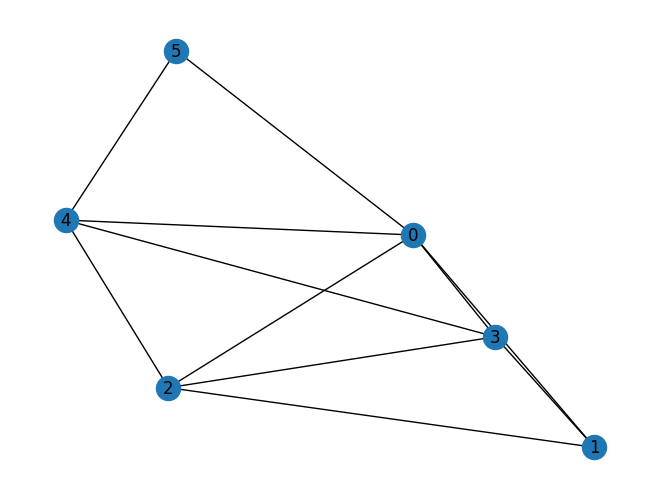

In [2]:
n_small = 6
graph = nx.Graph()
graph.add_nodes_from(np.arange(0, n_small, 1))
edge_list = [
    (0, 1),
    (0, 2),
    (0, 4),
    (1, 2),
    (2, 3),
    (3, 4),
    # (5, 2, 1.0),
    # (5, 3, 1.0),
    (5, 4),
    (2, 4),
    (3, 1),
    (5, 0),
    (0, 3)
]
graph.add_edges_from(edge_list)
nx.draw(graph, with_labels=True)

In [3]:
def build_maxcut_paulis(graph: nx.Graph):
    pauli_list = []
    
    for e in graph.edges():
        pauli_list.append(("ZZ", [e[0], e[1]], 1))
    return pauli_list

def build_maxclique_mis_paulis(graph: nx.Graph):
    complement = nx.complement(graph)
    # solve max independent set
    pauli_list = []
    A = 1
    for n in complement.nodes():
        pauli_list.append((("Z"), [n], A))

    B = 2/4
    for e in complement.edges():
        pauli_list.append(("II", [e[0], e[1]], B))
        pauli_list.append(("IZ", [e[0], e[1]], -B))
        pauli_list.append(("ZI", [e[0], e[1]], -B))
        pauli_list.append(("ZZ", [e[0], e[1]], B))
        
    return pauli_list

def build_kclique_paulis(graph, k):
    
    pauli_list = []
    B = 1
    A = B*k + 1
    observable_dict = dict()
    N = graph.number_of_edges()
    M = graph.number_of_edges()

    for n in graph.nodes():
        observable_dict[("Z", (n,))] = observable_dict.get(("Z", (n,)), 0) + A*k - A*0.5*N
        for m in graph.nodes():
            if n >= m:
                continue
            observable_dict[("ZZ", (n,m))] = observable_dict.get(("ZZ", (n,m)), 0) + A*0.5

    for e in graph.edges():
        observable_dict[("Z", (e[1],))] = observable_dict.get(("Z", (e[1],)), 0) + B/4
        observable_dict[("Z", (e[0],))] = observable_dict.get(("Z", (e[0],)), 0) + B/4
        sorted_nm = sorted([e[0], e[1]])
        observable_dict[("ZZ", (sorted_nm[0],sorted_nm[1]))] = observable_dict.get(("ZZ", (sorted_nm[0], sorted_nm[1])), 0) - B/4


    for (pauli, qubits), coeff in observable_dict.items():
        pauli_list.append((pauli, list(qubits), coeff))
    return pauli_list

def build_kclique_paulis_mis(graph, k):
    
    complement = nx.complement(graph)
    pauli_list = []
    B = 1
    A = B*k + 1
    observable_dict = dict()
    N = graph.number_of_nodes()
    M = graph.number_of_edges()

    for n in graph.nodes():
        observable_dict[("Z", (n,))] = observable_dict.get(("Z", (n,)), 0) + A*k - A*0.5*N
        for m in graph.nodes():
            if n >= m:
                continue
            observable_dict[("ZZ", (n,m))] = observable_dict.get(("ZZ", (n,m)), 0) + A*0.5

    for e in complement.edges():
        observable_dict[("Z", (e[1],))] = observable_dict.get(("Z", (e[1],)), 0) - B/4
        observable_dict[("Z", (e[0],))] = observable_dict.get(("Z", (e[0],)), 0) - B/4
        sorted_nm = sorted([e[0], e[1]])
        observable_dict[("ZZ", (sorted_nm[0],sorted_nm[1]))] = observable_dict.get(("ZZ", (sorted_nm[0], sorted_nm[1])), 0) + B/4


    for (pauli, qubits), coeff in observable_dict.items():
        pauli_list.append((pauli, list(qubits), coeff))

    return pauli_list


paulis = build_kclique_paulis_mis(graph, 4)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, n_small)
print(cost_hamiltonian)

SparsePauliOp(['IIIIIZ', 'IIIIZZ', 'IIIZIZ', 'IIZIIZ', 'IZIIIZ', 'ZIIIIZ', 'IIIIZI', 'IIIZZI', 'IIZIZI', 'IZIIZI', 'ZIIIZI', 'IIIZII', 'IIZZII', 'IZIZII', 'ZIIZII', 'IIZIII', 'IZZIII', 'ZIZIII', 'IZIIII', 'ZZIIII', 'ZIIIII'],
              coeffs=[5.  +0.j, 2.5 +0.j, 2.5 +0.j, 2.5 +0.j, 2.5 +0.j, 2.5 +0.j, 4.5 +0.j,
 2.5 +0.j, 2.5 +0.j, 2.75+0.j, 2.75+0.j, 4.75+0.j, 2.5 +0.j, 2.5 +0.j,
 2.75+0.j, 4.75+0.j, 2.5 +0.j, 2.75+0.j, 4.75+0.j, 2.5 +0.j, 4.25+0.j])


In [230]:
num_layers = 3
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=num_layers)
circuit.measure_all()
print(circuit)
print(circuit.parameters)

        ┌──────────────────────────────────────┐ ░ ┌─┐               
   q_0: ┤0                                     ├─░─┤M├───────────────
        │                                      │ ░ └╥┘┌─┐            
   q_1: ┤1                                     ├─░──╫─┤M├────────────
        │                                      │ ░  ║ └╥┘┌─┐         
   q_2: ┤2                                     ├─░──╫──╫─┤M├─────────
        │  QAOA(γ[0],β[0],γ[1],β[1],γ[2],β[2]) │ ░  ║  ║ └╥┘┌─┐      
   q_3: ┤3                                     ├─░──╫──╫──╫─┤M├──────
        │                                      │ ░  ║  ║  ║ └╥┘┌─┐   
   q_4: ┤4                                     ├─░──╫──╫──╫──╫─┤M├───
        │                                      │ ░  ║  ║  ║  ║ └╥┘┌─┐
   q_5: ┤5                                     ├─░──╫──╫──╫──╫──╫─┤M├
        └──────────────────────────────────────┘ ░  ║  ║  ║  ║  ║ └╥┘
meas: 6/════════════════════════════════════════════╩══╩══╩══╩══╩══╩═
                    

AerSimulator('aer_simulator')


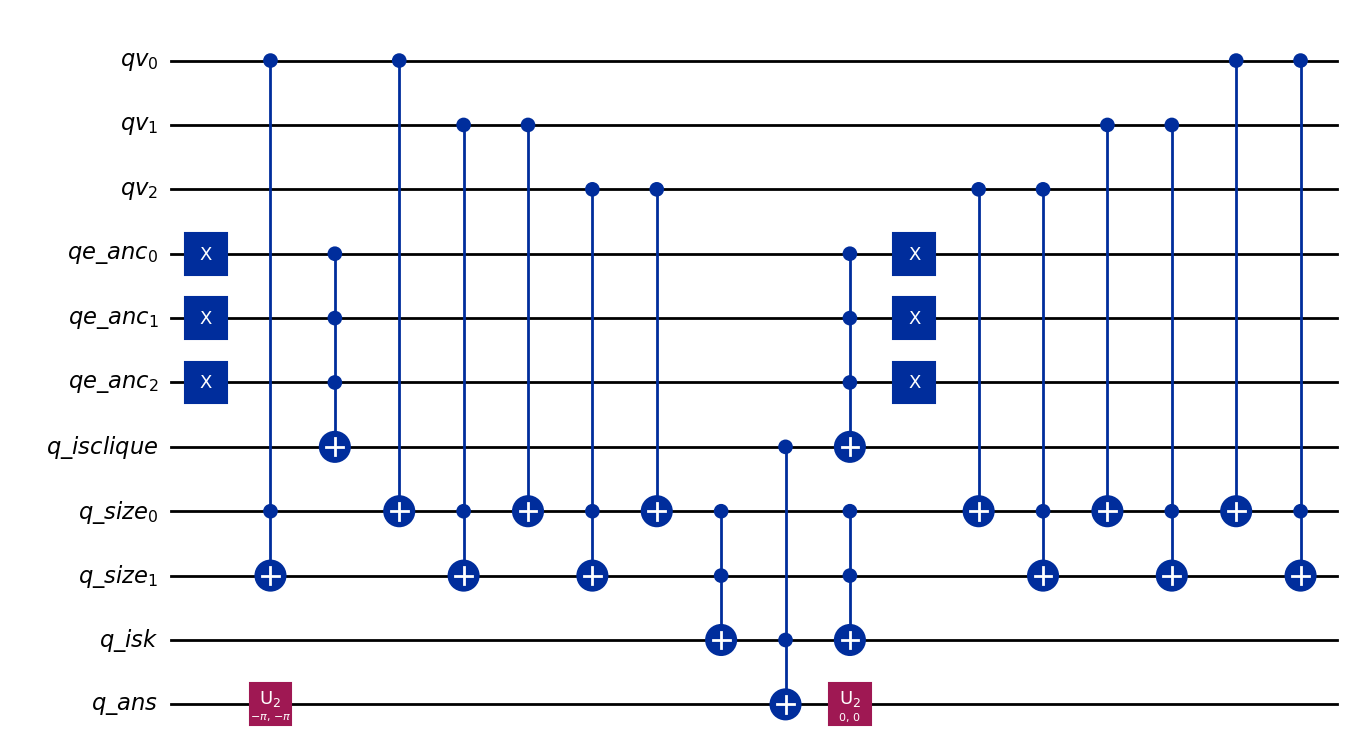

In [ ]:
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator

use_simulator = True
if not use_simulator:
    service = QiskitRuntimeService()

    backend = service.least_busy(
        operational=True, simulator=False, min_num_qubits=127
    )
else:
    backend = AerSimulator()
print(backend)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -4.856522382707704
       x: [ 1.397e+00  1.487e+00  1.627e-01  1.084e+00  2.036e-01
            1.000e+00]
    nfev: 43
   maxcv: 0.0


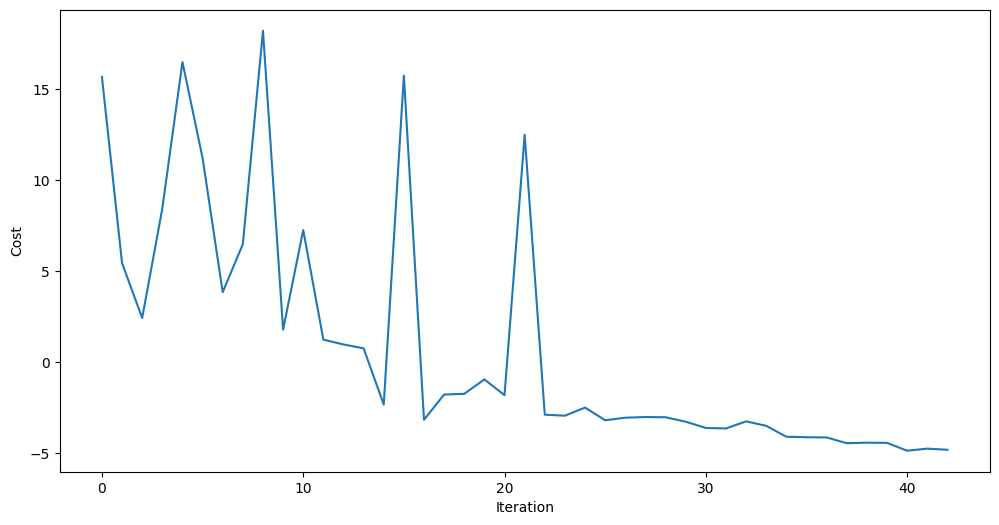

In [237]:
from scipy.optimize import minimize


objective_func_evals = []

initial_beta = np.pi
initial_gamma = np.pi / 2
if use_simulator:
    initial_params = np.random.rand(2*num_layers)
else:
    initial_params = [ 4.009e+00,  3.569e+00,  2.692e+00,  2.168e+00] # paste locally found variables here

def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    result = job.result()[0]
    cost = result.data.evs
    objective_func_evals.append(cost)

    return cost

# estimator = Estimator(mode=backend)
estimator = StatevectorEstimator()
# estimator.options.default_shots = 1000

# estimator.options.dynamical_decoupling.enable = True
# estimator.options.dynamical_decoupling.sequence_type = "XY4"
# estimator.options.twirling.enable_gates = True
# estimator.options.twirling.num_randomizations = "auto"
# estimator.options.environment.job_tags = ["TUT_QAOA"]
if use_simulator:
    candidate_circuit_no_meas = candidate_circuit.remove_final_measurements(inplace=False)

    result = minimize(
        cost_func_estimator,
        initial_params,
        args=(candidate_circuit_no_meas, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2
    )
    print(result)

    plt.figure(figsize=(12, 6))
    plt.plot(objective_func_evals)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()

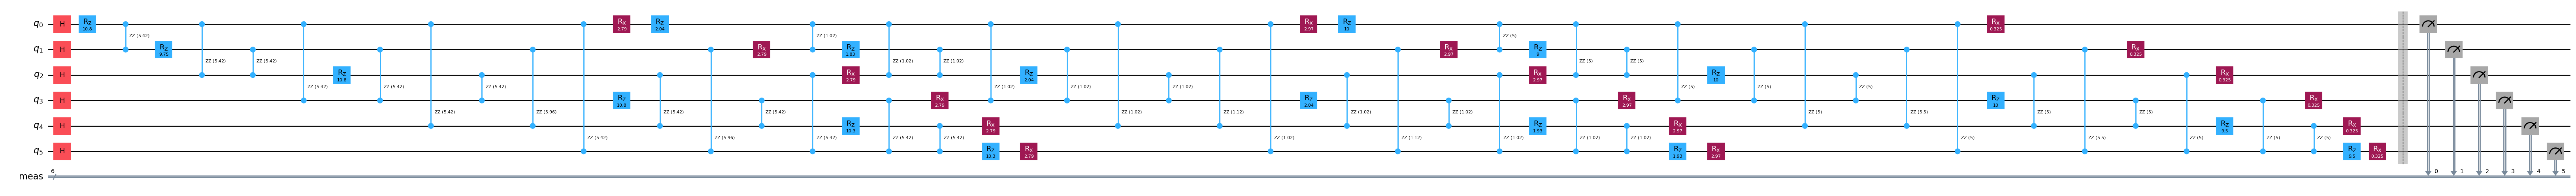

In [238]:
if use_simulator:
    optimized_circuit = candidate_circuit.assign_parameters(result.x)
else:
    optimized_circuit = candidate_circuit.assign_parameters(initial_params)
optimized_circuit.draw("mpl", fold=False, idle_wires=False)

In [ ]:

# backend = service.least_busy(
#     operational=True, simulator=False, min_num_qubits=127
# )

sampler = Sampler(mode=backend)
sampler.options.default_shots = 1000

sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

sampler.options.environment.job_tags = ["TUT_QAOA"]

pub = (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
print(final_distribution_int)

{61: 0.0511, 17: 0.0061, 35: 0.0346, 28: 0.0278, 42: 0.0346, 22: 0.0378, 15: 0.0158, 44: 0.027, 50: 0.0573, 56: 0.0229, 25: 0.0258, 19: 0.0393, 14: 0.0265, 45: 0.0157, 37: 0.0275, 60: 0.0118, 9: 0.0123, 26: 0.0368, 3: 0.0068, 21: 0.0276, 38: 0.0382, 52: 0.0291, 41: 0.0246, 31: 0.0204, 63: 0.0378, 49: 0.0265, 0: 0.0114, 55: 0.0055, 7: 0.029, 1: 0.0005, 36: 0.0047, 47: 0.0218, 53: 0.0122, 29: 0.0151, 13: 0.0269, 58: 0.0038, 16: 0.0005, 40: 0.0051, 11: 0.0326, 48: 0.0106, 33: 0.0058, 5: 0.0121, 57: 0.011, 24: 0.0066, 10: 0.0069, 20: 0.004, 46: 0.0007, 23: 0.0012, 34: 0.0027, 43: 0.0009, 54: 0.0044, 51: 0.0041, 12: 0.0114, 6: 0.0071, 62: 0.0064, 27: 0.0012, 59: 0.0043, 18: 0.0036, 30: 0.0009, 8: 0.001, 32: 0.0004, 39: 0.0007, 4: 0.001, 2: 0.0002}


In [240]:
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]


keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)


Result bitstring: [0, 1, 0, 0, 1, 1]


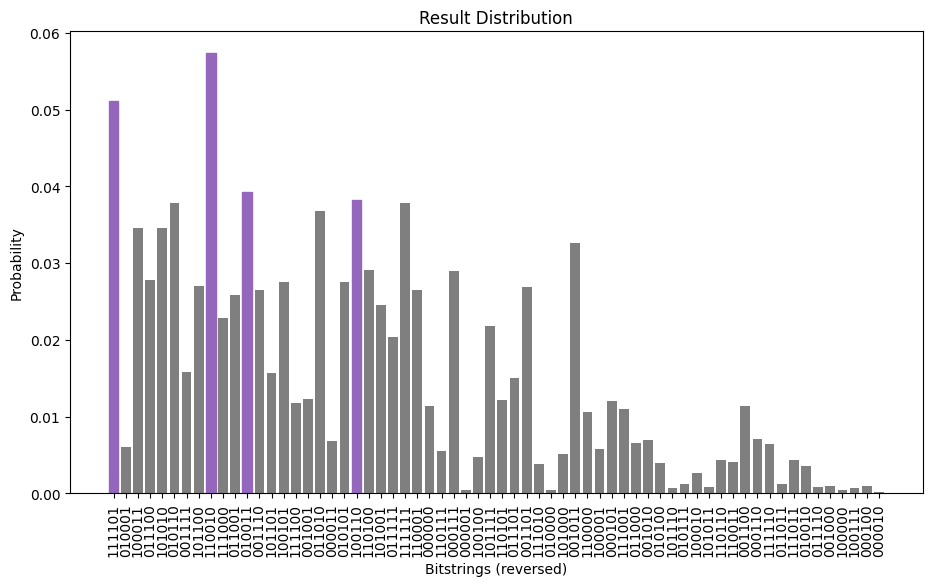

In [241]:
plt.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=90)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p[0])].set_color("tab:purple")
plt.show()

Max clique size: 3


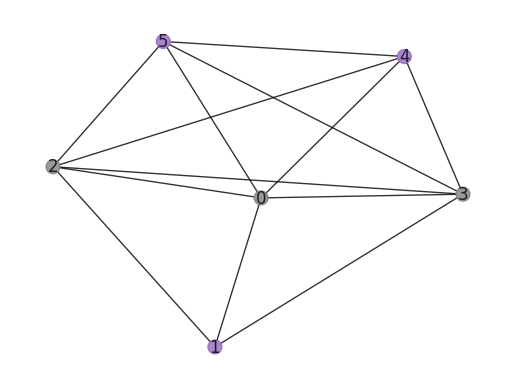

In [242]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos, with_labels=True
    )
    cut_size = 0
    for e in G.edge_list():
        cut_size = cut_size + (1 if x[e[0]] != x[e[1]] else 0)

    print(f"Cut size: {cut_size}")

def plot_maxclique_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos, with_labels=True
    )

    clique_size = 0
    for i in x:
        clique_size += i

    print(f"Max clique size: {clique_size}")

plot_maxclique_result(graph, most_likely_bitstring)

In [450]:
def generate_graph_with_k_clique(n, p, k):
    graph = nx.erdos_renyi_graph(n, p)
    clique_nodes = np.arange(n)
    np.random.shuffle(clique_nodes)
    clique_nodes = clique_nodes[:k]
    # print(clique_nodes)
    edges_to_add = []
    for node1 in clique_nodes:
        for node2 in clique_nodes:
            if node1 == node2:
                continue
            if not graph.has_edge(node1, node2) and (node1, node2) not in edges_to_add:
                edges_to_add.append((node1, node2))
    graph.add_edges_from(edges_to_add)
    return graph

In [442]:
def is_clique(graph: nx.Graph, solution):
    solution_npy = np.array(solution)
    mask = solution_npy == 1
    node_indices = np.array(list(graph.nodes()))[mask]
    for n1 in node_indices:
        for n2 in node_indices:
            if n1 == n2:
                continue
            if not graph.has_edge(n1, n2):
                return False
    return True

In [443]:
def validate_max_clique_solutions(graph, solution, max_size):
    is_valid = is_clique(graph, solution)
    return {
        "is_valid_clique": is_valid,
        "is_max_clique": sum(solution) == max_size and is_valid
    }

def validate_k_clique_solutions(graph, solutions, k):
    valid_cliques = 0
    k_cliques = 0
    for solution in solutions:
        is_valid = is_clique(graph, solution)
        is_k_clique = sum(solution) == k and is_valid
        valid_cliques += 1 if is_valid else 0
        k_cliques += 1 if is_k_clique else 0
    return {
        "valid_cliques": valid_cliques,
        "k_cliques": k_cliques,
        "found_solution": k_cliques > 0
    }

In [466]:
def generate_k_clique_instance(size_info):
    return generate_graph_with_k_clique(size_info["n"], size_info["p"], size_info["k"])

def generate_max_clique_instance(size_info):
    return generate_graph_with_k_clique(size_info["n"], size_info["p"], size_info["k"])

In [ ]:
# experiments
from tqdm import tqdm


def test_graph(graph, problem, validate_solutions, iters=5, num_layers=3):

    validation_results = []
    estimator = StatevectorEstimator()
    backend = AerSimulator()
    sampler = Sampler(mode=backend)
    sampler.options.default_shots = 1000
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    paulis = problem(graph)
    cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, graph.number_of_nodes())

    circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=num_layers)
    circuit.measure_all()
    candidate_circuit = pm.run(circuit)
    candidate_circuit_no_meas = candidate_circuit.remove_final_measurements(inplace=False)
    found_bitstrings = []
    cumulative_optimized_circuit_depth = 0
    avg_number_evaluations = 0
    for i in tqdm(range(iters)):


        initial_params = np.random.rand(2*num_layers) * 2 * np.pi


        result = minimize(
            cost_func_estimator,
            initial_params,
            args=(candidate_circuit_no_meas, cost_hamiltonian, estimator),
            method="COBYLA",
            options={"maxiter": 200},
            tol=1e-2
        )
        # print(f"Energy: {cost_func_estimator(result.x, candidate_circuit_no_meas, cost_hamiltonian, estimator)}")
        optimized_circuit = candidate_circuit.assign_parameters(result.x)
        cumulative_optimized_circuit_depth += optimized_circuit.depth()
        avg_number_evaluations += result.nfev

        pub = (optimized_circuit, )
        job = sampler.run([pub], shots=1000)
        counts_int = job.result()[0].data.meas.get_int_counts()

        most_likely = max(counts_int, key=counts_int.get)

        most_likely_bitstring = to_bitstring(most_likely, graph.number_of_nodes())
        most_likely_bitstring.reverse()

        # print("Result bitstring:", most_likely_bitstring)
        found_bitstrings.append(most_likely_bitstring)
    
    validation_results = validate_solutions(found_bitstrings)
    # print(f"Valid cliques: {valid_cliques}/{iters}")
    # print(f"Valid k-cliques: {k_cliques}/{iters}")

    average_opimized_circuit_depth = cumulative_optimized_circuit_depth / iters
    avg_number_evaluations /= iters
    return validation_results, average_opimized_circuit_depth, avg_number_evaluations


def test_num_layers(graph, layers, problem, validate_solutions, iters=10):
    validation_results_per_layer = []
    average_optimized_circuit_depth_per_layer = []
    for num in layers:
        print(f"--- Num layers: {num}")
        validation_results, optimized_circuit_depth, _ = test_graph(
            graph, 
            problem=problem, 
            validate_solutions=validate_solutions,
            iters=iters, 
            num_layers=num)
        average_optimized_circuit_depth_per_layer.append(optimized_circuit_depth)
        validation_results_per_layer.append(validation_results)
        
    return validation_results_per_layer, average_optimized_circuit_depth_per_layer

def test_problem_sizes(sizes, generate_instance, instance_count, problem, validate_solutions, layers=4, iters=10):
    validation_results_per_size = []
    depths_per_size = []
    evaluations_per_size = []
    for s in sizes:
        print(f"--- Problem size: {s}")
        graphs = [generate_instance(s) for i in range(instance_count)]
        validation_results_for_graphs = []
        evaluations_per_graph = []
        depths_per_graph = []
        for graph in graphs:
            validation_results, optimized_circuit_depth, avg_num_evaluations = test_graph(
                graph, 
                problem=problem, 
                validate_solutions=lambda x: validate_solutions(graph, x, s),
                iters=iters, 
                num_layers=layers)
            
            validation_results_for_graphs.append(validation_results)
            evaluations_per_graph.append(avg_num_evaluations)
            depths_per_graph.append(optimized_circuit_depth)
            
        validation_results_per_size.append(validation_results_for_graphs)
        depths_per_size.append(depths_per_graph)
        evaluations_per_size.append(evaluations_per_graph)
        
    return validation_results_per_size, depths_per_size, evaluations_per_size

In [569]:
# max-clique
num_graphs = 5
num_layers = [2, 4]
results_per_layer_max_clique = [[] for l in range(len(num_layers))]
max_clique_size = 6
graphs = [generate_graph_with_k_clique(8, 0.4, max_clique_size) for i in range(num_graphs)]
for i in tqdm(range(num_graphs)):
    graph = graphs[i]
    # nx.draw(graph, with_labels=True)
    validation_results = test_num_layers(graph, 
                                        num_layers, 
                                        problem=lambda x: build_maxclique_mis_paulis(x), 
                                        validate_solution=lambda x: validate_max_clique_solution(graph, x, max_clique_size), 
                                        iters=5)
    for l in range(len(num_layers)):
        results_per_layer_max_clique[l].extend(validation_results[l])

  0%|          | 0/5 [00:00<?, ?it/s]


TypeError: test_num_layers() got an unexpected keyword argument 'validate_solution'. Did you mean 'validate_solutions'?

In [528]:
# k-clique
num_graphs = 2
layers = [1, 2, 3, 4]
iters_k_clique = 1
k_clique_size = 4
k_clique_layers_results = {
    "num_graphs" : num_graphs,
    "iters_per_graph": iters_k_clique,
    "k": k_clique_size
}
graphs = [generate_graph_with_k_clique(8, 0.4, k_clique_size) for i in range(num_graphs)]
for i in tqdm(range(num_graphs)):
    graph = graphs[i]
    validation_results, avg_opt_circuit_depth_per_layer = test_num_layers(graph, 
                                                                        layers, 
                                                                        problem=lambda g: build_kclique_paulis_mis(g, k_clique_size), 
                                                                        validate_solutions=lambda x: validate_k_clique_solutions(graph, x, k_clique_size), 
                                                                        iters=iters_k_clique)
    # plt.figure()
    # nx.draw(graph, with_labels=True)
    print(validation_results)
    for l in range(len(layers)):
        results_per_layer = k_clique_layers_results.get("results_per_layer", dict())
        layer_results = results_per_layer.get(layers[l], [])
        layer_results.append(validation_results[l])
        results_per_layer[layers[l]] = layer_results
        k_clique_layers_results["results_per_layer"] = results_per_layer

        depths_per_layer = k_clique_layers_results.get("depths_per_layer", dict())
        depths_per_layer[layers[l]] = depths_per_layer.get(layers[l], 0) + avg_opt_circuit_depth_per_layer[l] / num_graphs
        k_clique_layers_results["depths_per_layer"] = depths_per_layer

  0%|          | 0/2 [00:00<?, ?it/s]

--- Num layers: 1


100%|██████████| 1/1 [00:00<00:00,  2.54it/s]


--- Num layers: 2


100%|██████████| 1/1 [00:00<00:00,  2.00it/s]


...

--- Num layers: 3


100%|██████████| 1/1 [00:01<00:00,  1.48s/it]


--- Num layers: 4


100%|██████████| 2/2 [00:11<00:00,  5.79s/it]

[{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}]


In [530]:
k_clique_layers_results

{'num_graphs': 2,
 'iters_per_graph': 1,
 'k': 4,
 'results_per_layer': {1: [{'valid_cliques': 1,
    'k_cliques': 0,
    'found_solution': False},
   {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}],
  2: [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False},
   {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}],
  3: [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False},
   {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}],
  4: [{'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False},
   {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}]},
 'depths_per_layer': {1: 18.0, 2: 27.0, 3: 36.0, 4: 45.0}}

In [531]:
import json
with open("k_clique_layers_results.json", "w") as f:
    json.dump(k_clique_layers_results, f)

In [508]:
import json
with open("k_clique_layers_results.json", "r") as f:
    k_clique_layers_results = json.load(f)

In [588]:
# k-clique problem size testing
def benchmark_problem_sizes(problem_sizes, output_filename, paulis_generator, validate_solutions, num_graphs=3, iters_per_graph=5):
    out_dict = dict()
    out_dict["problem_sizes"] = problem_sizes
    out_dict["num_graphs"] = num_graphs
    out_dict["iters_per_graph"] = iters_per_graph
    results_per_layer_k_clique_sizes = [[] for l in range(len(problem_sizes))]
    validation_results, depths_per_size, evaluations_per_size = test_problem_sizes(problem_sizes, 
                                            generate_k_clique_instance,
                                            num_graphs, 
                                            problem=lambda x: paulis_generator(x, k_clique_size), 
                                            validate_solutions=validate_solutions,
                                            iters=iters_per_graph)
    print(validation_results)
    out_dict["results_per_size"] = validation_results
    out_dict["depths_per_size"] = depths_per_size
    out_dict["evaluations_per_size"] = evaluations_per_size

    with open("benchmarkResults/" + output_filename, "w") as f:
        json.dump(out_dict, f)
    return out_dict

In [589]:
# test different random graph number of nodes
benchmark_graph_size_results = benchmark_problem_sizes(
    [
        {"n": 4, "p": 0.4, "k": 3},
        {"n": 5, "p": 0.4, "k": 4},
        # {"n": 8, "p": 0.4, "k": 5},
    ],
    "results_graphs_n.json",
    paulis_generator=build_kclique_paulis_mis,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=2,
    iters_per_graph=2
)

--- Problem size: {'n': 4, 'p': 0.4, 'k': 3}


100%|██████████| 2/2 [00:00<00:00,  2.96it/s]


--- Problem size: {'n': 5, 'p': 0.4, 'k': 4}


100%|██████████| 2/2 [00:00<00:00,  2.58it/s]

[[{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}], [{'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}]]


In [562]:
# test different random graph densities
benchmark_problem_sizes(
    [
        {"n": 7, "p": 0.3, "k": 4},
        {"n": 7, "p": 0.5, "k": 4},
        {"n": 7, "p": 0.7, "k": 4},
    ],
    "results_graphs_p.json",
    paulis_generator=build_kclique_paulis_mis,
    validate_solutions=lambda g,x,p: validate_k_clique_solutions(g, x, p["k"]),
    num_graphs=5,
    iters_per_graph=8
)

--- Problem size: {'n': 7, 'p': 0.3, 'k': 4}


100%|██████████| 8/8 [00:14<00:00,  1.85s/it]


--- Problem size: {'n': 7, 'p': 0.5, 'k': 4}


100%|██████████| 8/8 [00:16<00:00,  2.04s/it]


--- Problem size: {'n': 7, 'p': 0.7, 'k': 4}


100%|██████████| 8/8 [00:15<00:00,  1.99s/it]


{'problem_sizes': [{'n': 7, 'p': 0.3, 'k': 4},
  {'n': 7, 'p': 0.5, 'k': 4},
  {'n': 7, 'p': 0.7, 'k': 4}],
 'num_graphs': 5,
 'iters_per_graph': 8,
 'results_per_size': [[({'valid_cliques': 1,
     'k_cliques': 0,
     'found_solution': False},
    40.0),
   ({'valid_cliques': 3, 'k_cliques': 3, 'found_solution': True}, 40.0),
   ({'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, 40.0),
   ({'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, 40.0),
   ({'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, 40.0)],
  [({'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, 40.0),
   ({'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}, 40.0),
   ({'valid_cliques': 2, 'k_cliques': 2, 'found_solution': True}, 40.0),
   ({'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, 40.0),
   ({'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, 40.0)],
  [({'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, 40.0),
   ({'v

In [542]:
benchmark_graph_size_results

{'problem_sizes': [{'n': 4, 'p': 0.5, 'k': 3}, {'n': 7, 'p': 0.4, 'k': 4}],
 'num_graphs': 2,
 'iters_per_graph': 3,
 'results_per_size': [[({'valid_cliques': 0,
     'k_cliques': 0,
     'found_solution': False},
    25.0),
   ({'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, 25.0)],
  [({'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}, 40.0),
   ({'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, 40.0)]]}

In [406]:
# max clique
valid_cliques = [sum([1 if s["is_valid_clique"] else 0 for s in solutions]) for solutions in results_per_layer_max_clique]
max_cliques = [sum([1 if s["is_max_clique"] else 0 for s in solutions]) for solutions in results_per_layer_max_clique]
print(valid_cliques)
print(max_cliques)

NameError: name 'results_per_layer_max_clique' is not defined

In [512]:
# k-clique
print(k_clique_layers_results)
valid_cliques_k_clique = [sum([g["valid_cliques"] for g in v]) for k,v in k_clique_layers_results["results_per_layer"].items()]
k_cliques = [sum([g["k_cliques"] for g in v]) for k,v in k_clique_layers_results["results_per_layer"].items()]
found_solutions = [sum([g["found_solution"] for g in v]) for k,v in k_clique_layers_results["results_per_layer"].items()]
print(valid_cliques_k_clique)
print(k_cliques)
print(found_solutions)

{'num_graphs': 2, 'iters_per_graph': 2, 'k': 4, 'results_per_layer': {'2': [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 0, 'found_solution': False}], '3': [{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}]}}
[1, 0]
[0, 0]
[0, 0]


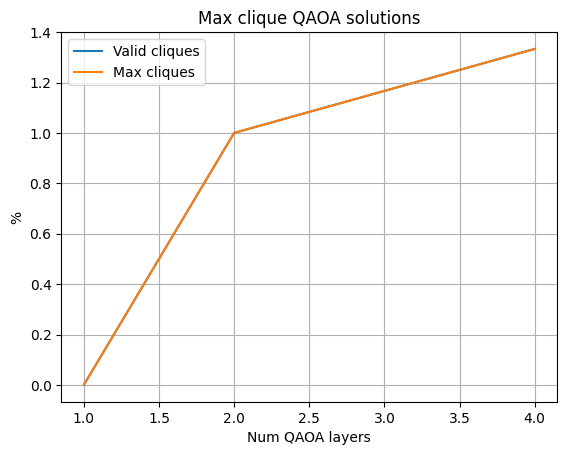

In [361]:
plt.figure()
plt.title("Max clique QAOA solutions")
plt.plot(num_layers, np.array(valid_cliques) / len(valid_cliques), label="Valid cliques")
plt.plot(num_layers, np.array(max_cliques) / len(valid_cliques), label="Max cliques")
plt.ylabel("%")
plt.xlabel("Num QAOA layers")
plt.grid()
plt.legend()
plt.show()

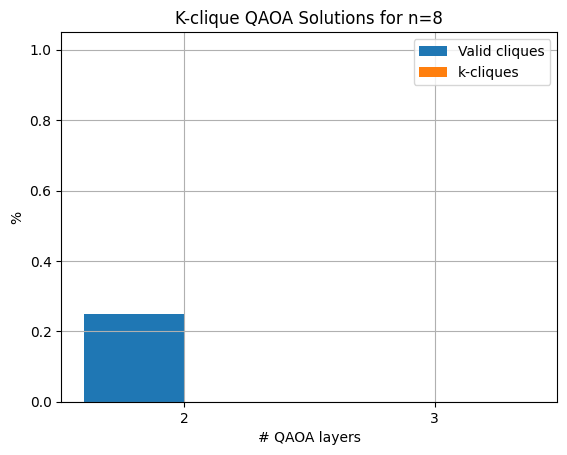

In [518]:
plt.figure()
plt.title("K-clique QAOA Solutions for n=8")
w = 0.4
num_tests = k_clique_layers_results["num_graphs"] * k_clique_layers_results["iters_per_graph"]
num_layers = len(k_clique_layers_results["results_per_layer"])
plt.xticks(np.arange(num_layers), list(k_clique_layers_results["results_per_layer"].keys()))
plt.ylabel("%")
plt.bar(np.arange(num_layers) - w/2, np.array(valid_cliques_k_clique) / num_tests, width=w, label="Valid cliques")
plt.bar(np.arange(num_layers) + w/2, np.array(k_cliques) / num_tests, width=w, label="k-cliques")
# plt.bar(np.arange(len(num_layers)) + w/3, np.array(found_solutions) / num_graphs, width=w/3, label="found solutions")
plt.ylim(0, 1.05)
plt.xlabel("# QAOA layers")
plt.grid()
plt.legend()
plt.show()

{'problem_sizes': [{'n': 4, 'p': 0.4, 'k': 3}, {'n': 5, 'p': 0.4, 'k': 4}], 'num_graphs': 2, 'iters_per_graph': 2, 'results_per_size': [[{'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}, {'valid_cliques': 1, 'k_cliques': 1, 'found_solution': True}], [{'valid_cliques': 2, 'k_cliques': 1, 'found_solution': True}, {'valid_cliques': 0, 'k_cliques': 0, 'found_solution': False}]], 'depths_per_size': [[25.0, 25.0], [30.0, 30.0]], 'evaluations_per_size': [[46.5, 50.0], [45.0, 43.5]]}
[1, 2]
[1, 1]
[1, 1]


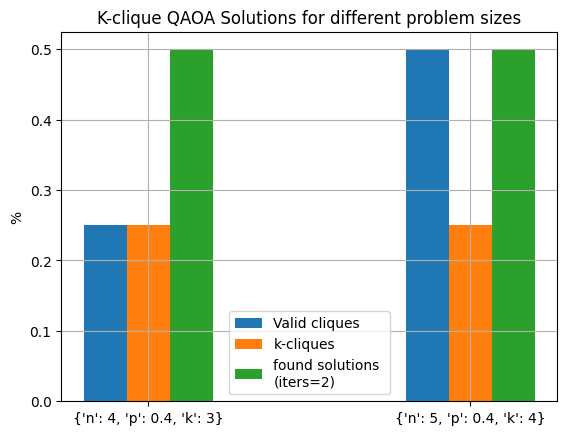

In [590]:
# k-clique problem sizes
with open("benchmarkResults/results_graphs_n.json", "r") as f:
    benchmark_graph_size_results = json.load(f)

print(benchmark_graph_size_results)
valid_cliques_k_clique_sizes = [sum([g["valid_cliques"] for g in s]) for s in benchmark_graph_size_results["results_per_size"]]
k_cliques_sizes = [sum([g["k_cliques"] for g in s]) for s in benchmark_graph_size_results["results_per_size"]]
found_solutions_sizes = [sum([g["found_solution"] for g in s]) for s in benchmark_graph_size_results["results_per_size"]]
print(valid_cliques_k_clique_sizes)
print(k_cliques_sizes)
print(found_solutions_sizes)

plt.figure()
plt.title("K-clique QAOA Solutions for different problem sizes")
w = 0.4
num_tests_sizes = benchmark_graph_size_results["num_graphs"] * benchmark_graph_size_results["iters_per_graph"]
num_problem_sizes = len(benchmark_graph_size_results["problem_sizes"])
plt.xticks(np.arange(num_problem_sizes), benchmark_graph_size_results["problem_sizes"])
plt.ylabel("%")
plt.bar(np.arange(num_problem_sizes) - w/3, np.array(valid_cliques_k_clique_sizes) / num_tests_sizes, width=w/3, label="Valid cliques")
plt.bar(np.arange(num_problem_sizes), np.array(k_cliques_sizes) / num_tests_sizes, width=w/3, label="k-cliques")
plt.bar(np.arange(num_problem_sizes) + w/3, np.array(found_solutions_sizes) / benchmark_graph_size_results["num_graphs"] , width=w/3, label=f"found solutions \n(iters={benchmark_graph_size_results["iters_per_graph"]})")
plt.grid()
plt.legend()
plt.show()

[4, 5] [25.0, 30.0]


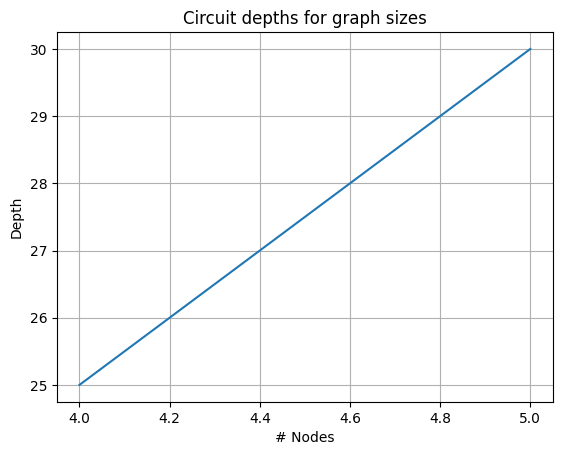

In [587]:
# plot circuit depths
with open("results_graphs_n.json", "r") as f:
    benchmark_results = json.load(f)
depths = [sum(s) / benchmark_results["num_graphs"] for s in benchmark_results["depths_per_size"]]
plt.figure()
plt.title("Circuit depths for graph sizes")
graph_sizes = [s["n"] for s in benchmark_graph_size_results["problem_sizes"]]
# plt.xticks(np.arange(num_problem_sizes), [s["n"] for s in benchmark_graph_size_results["problem_sizes"]])
plt.ylabel("Depth")
plt.xlabel("# Nodes")
print(graph_sizes, depths)
plt.plot(graph_sizes, depths)
plt.grid()
# plt.legend()
plt.show()

In [461]:
import dill
dill.dump_session('notebook_env.db')